In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

print("SHAP version:", shap.__version__)
print("Imports done ✅")

c:\Users\Kenen\Desktop\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP version: 0.45.0
Imports done ✅


In [2]:
# Load saved models
xgb_fraud = joblib.load('../models/xgboost_fraud.pkl')
xgb_cc = joblib.load('../models/xgboost_creditcard.pkl')

# Load test data
X_test_fraud = pd.read_csv('../data/processed/X_test.csv')
y_test_fraud = pd.read_csv('../data/processed/y_test.csv').squeeze()

cc_X_test = pd.read_csv('../data/processed/cc_X_test.csv')
cc_y_test = pd.read_csv('../data/processed/cc_y_test.csv').squeeze()

print("Fraud test shape:", X_test_fraud.shape)
print("Credit card test shape:", cc_X_test.shape)

Fraud test shape: (30223, 142)
Credit card test shape: (56962, 30)


In [3]:
print("Computing SHAP values for Fraud_Data XGBoost...")
explainer_fraud = shap.TreeExplainer(xgb_fraud)

# Use a sample for speed
sample_fraud = X_test_fraud.sample(500, random_state=42)
shap_values_fraud = explainer_fraud.shap_values(sample_fraud)

print("SHAP values computed ✅")
print("Shape:", shap_values_fraud.shape)

Computing SHAP values for Fraud_Data XGBoost...
SHAP values computed ✅
Shape: (500, 142)


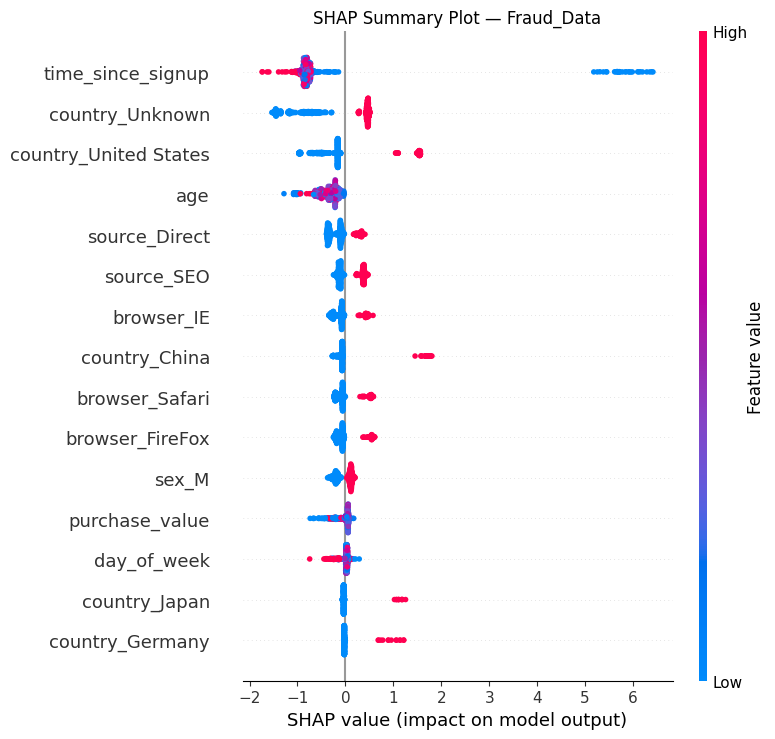

Summary plot saved ✅


In [4]:
plt.figure()
shap.summary_plot(
    shap_values_fraud,
    sample_fraud,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot — Fraud_Data")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_fraud.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary plot saved ✅")

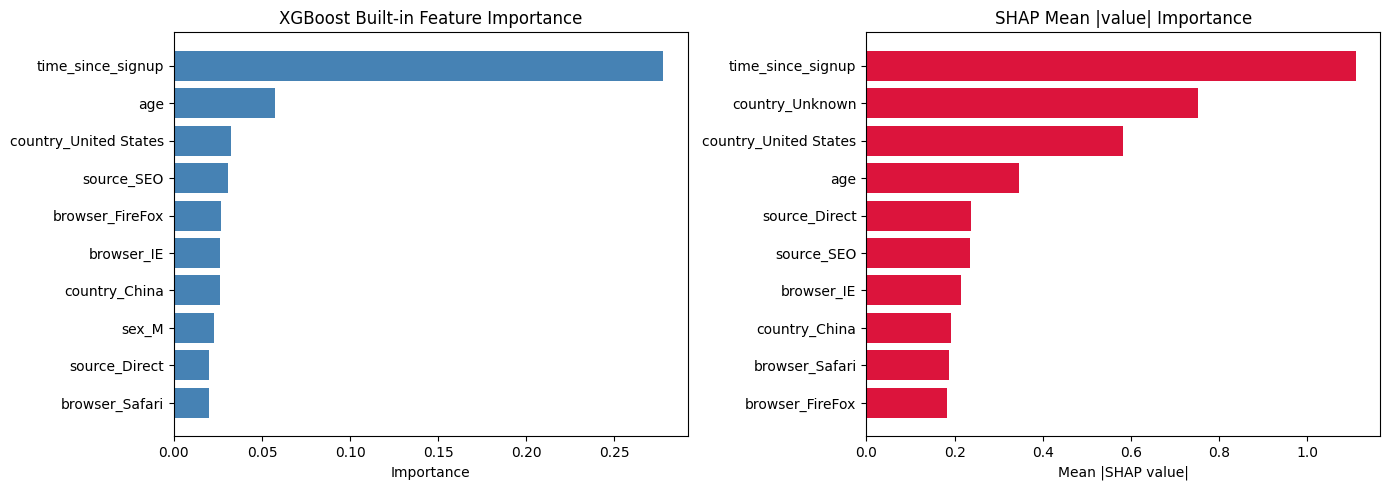


Top 5 SHAP features:
              feature  shap_importance
    time_since_signup         1.109073
      country_Unknown         0.752744
country_United States         0.581986
                  age         0.346067
        source_Direct         0.237096


In [5]:
# Built-in XGBoost feature importance
importance_df = pd.DataFrame({
    'feature': X_test_fraud.columns,
    'importance': xgb_fraud.feature_importances_
}).sort_values('importance', ascending=False).head(10)

# SHAP mean absolute values
shap_importance = pd.DataFrame({
    'feature': sample_fraud.columns,
    'shap_importance': np.abs(shap_values_fraud).mean(axis=0)
}).sort_values('shap_importance', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(importance_df['feature'][::-1], importance_df['importance'][::-1], color='steelblue')
axes[0].set_title('XGBoost Built-in Feature Importance')
axes[0].set_xlabel('Importance')

axes[1].barh(shap_importance['feature'][::-1], shap_importance['shap_importance'][::-1], color='crimson')
axes[1].set_title('SHAP Mean |value| Importance')
axes[1].set_xlabel('Mean |SHAP value|')

plt.tight_layout()
plt.savefig('../data/processed/feature_importance_comparison.png', dpi=150)
plt.show()

print("\nTop 5 SHAP features:")
print(shap_importance.head(5).to_string(index=False))

In [6]:
# Get predictions on full test set
y_pred_fraud = xgb_fraud.predict(X_test_fraud)
y_prob_fraud = xgb_fraud.predict_proba(X_test_fraud)[:, 1]

# Find examples
tp_idx = np.where((y_pred_fraud == 1) & (y_test_fraud.values == 1))[0][0]  # True Positive
fp_idx = np.where((y_pred_fraud == 1) & (y_test_fraud.values == 0))[0][0]  # False Positive
fn_idx = np.where((y_pred_fraud == 0) & (y_test_fraud.values == 1))[0][0]  # False Negative

print(f"True Positive  index: {tp_idx} | prob: {y_prob_fraud[tp_idx]:.4f}")
print(f"False Positive index: {fp_idx} | prob: {y_prob_fraud[fp_idx]:.4f}")
print(f"False Negative index: {fn_idx} | prob: {y_prob_fraud[fn_idx]:.4f}")

True Positive  index: 2 | prob: 0.9968
False Positive index: 147 | prob: 0.6263
False Negative index: 17 | prob: 0.3732


=== TRUE POSITIVE (Correctly identified fraud) ===


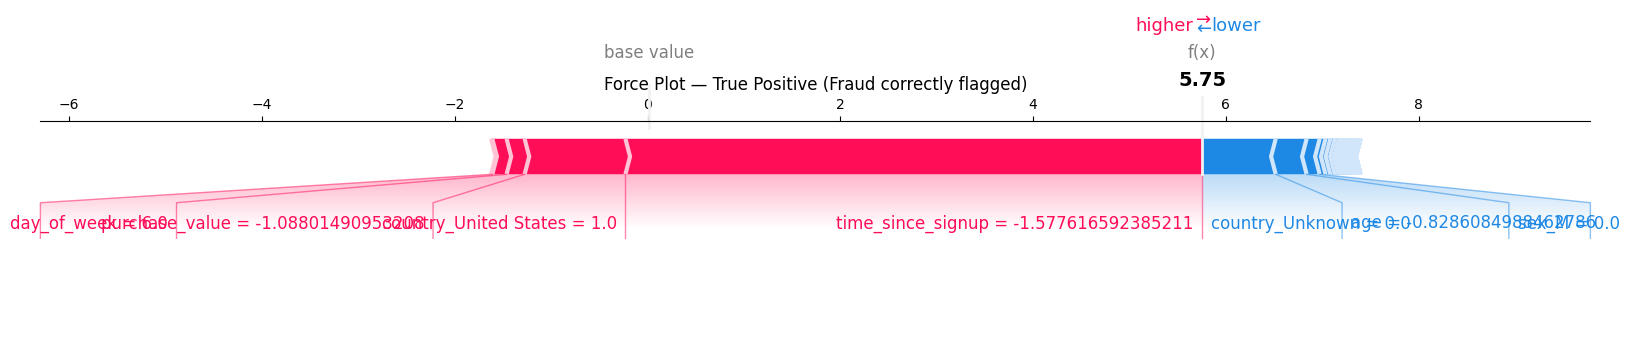

In [7]:
shap.initjs()

# Compute SHAP for full test set (needed for force plots)
explainer_full = shap.TreeExplainer(xgb_fraud)
shap_full = explainer_full.shap_values(X_test_fraud.iloc[:200])

print("=== TRUE POSITIVE (Correctly identified fraud) ===")
shap.force_plot(
    explainer_full.expected_value,
    shap_full[tp_idx],
    X_test_fraud.iloc[tp_idx],
    matplotlib=True,
    show=False
)
plt.title("Force Plot — True Positive (Fraud correctly flagged)")
plt.savefig('../data/processed/shap_force_tp.png', dpi=150, bbox_inches='tight')
plt.show()

=== FALSE POSITIVE (Legitimate flagged as fraud) ===


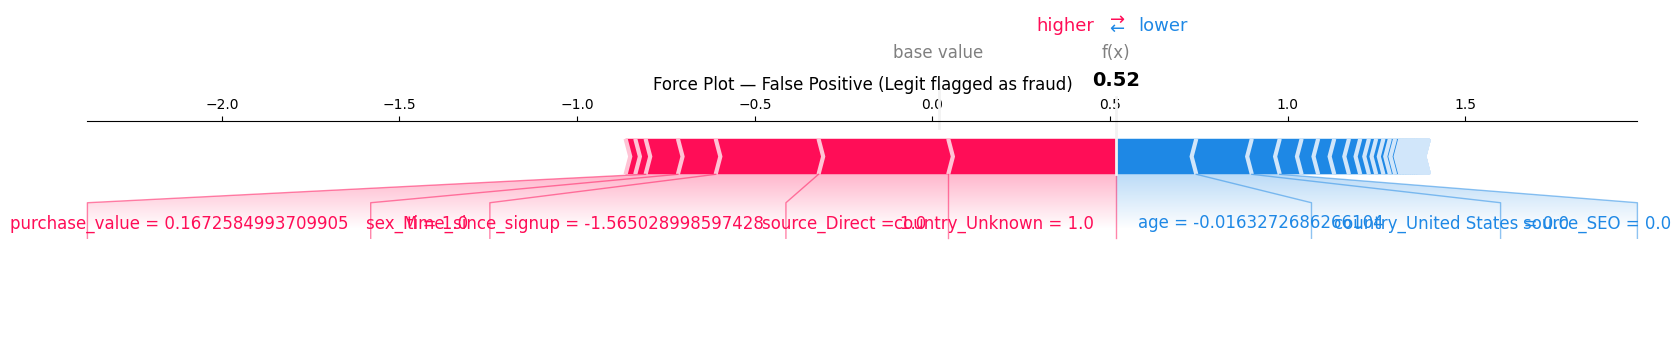

=== FALSE NEGATIVE (Missed fraud) ===


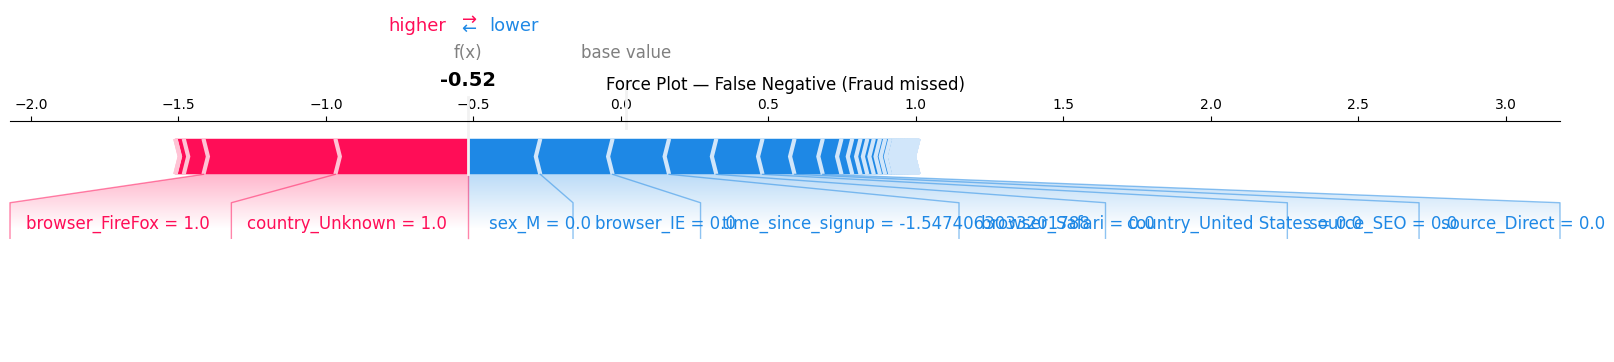

In [8]:
print("=== FALSE POSITIVE (Legitimate flagged as fraud) ===")
shap.force_plot(
    explainer_full.expected_value,
    shap_full[fp_idx],
    X_test_fraud.iloc[fp_idx],
    matplotlib=True,
    show=False
)
plt.title("Force Plot — False Positive (Legit flagged as fraud)")
plt.savefig('../data/processed/shap_force_fp.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== FALSE NEGATIVE (Missed fraud) ===")
shap.force_plot(
    explainer_full.expected_value,
    shap_full[fn_idx],
    X_test_fraud.iloc[fn_idx],
    matplotlib=True,
    show=False
)
plt.title("Force Plot — False Negative (Fraud missed)")
plt.savefig('../data/processed/shap_force_fn.png', dpi=150, bbox_inches='tight')
plt.show()

Computing SHAP values for Credit Card XGBoost...


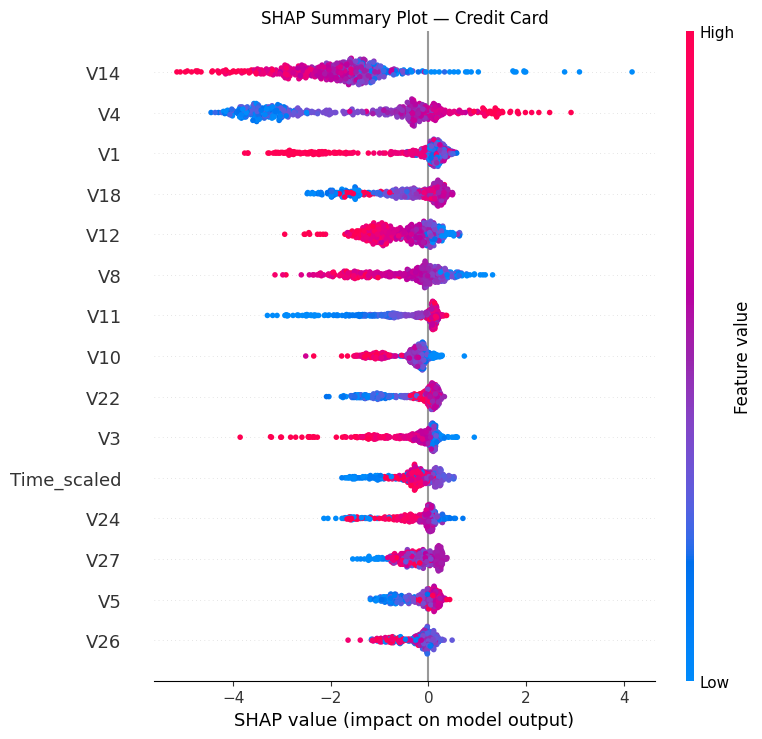

Credit card SHAP done ✅


In [10]:
print("Computing SHAP values for Credit Card XGBoost...")
explainer_cc = shap.TreeExplainer(xgb_cc)

sample_cc = cc_X_test.sample(500, random_state=42)
shap_values_cc = explainer_cc.shap_values(sample_cc)

plt.figure()
shap.summary_plot(
    shap_values_cc,
    sample_cc,
    max_display=15,
    show=False
)
plt.title("SHAP Summary Plot — Credit Card")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Credit card SHAP done ✅")

recommendations = """
========================================================
   BUSINESS RECOMMENDATIONS — Adey Innovations Inc.
========================================================

Based on SHAP analysis of the XGBoost fraud detection model:

1. TIME-SINCE-SIGNUP RULE (Most important feature)
   - Transactions occurring within 24 hours of account 
     signup should trigger additional verification (OTP, 
     email confirmation, or manual review).
   - SHAP importance: 1.109 — strongest fraud predictor.

2. UNKNOWN COUNTRY / IP FLAGGING
   - Transactions where IP address cannot be mapped to 
     a country should be automatically held for review.
   - These represent anonymized or masked connections 
     (VPN, Tor) — a strong fraud indicator.
   - SHAP importance: 0.753

3. GEOLOCATION MONITORING
   - Build a country-level risk scoring system.
   - High fraud-rate countries (e.g. Pakistan) should 
     trigger step-up authentication automatically.

4. AGE-BASED RISK SCORING
   - Certain age groups show higher fraud correlation.
   - Incorporate age as a real-time risk scoring factor 
     in the transaction approval pipeline.
   - SHAP importance: 0.346

5. DIRECT TRAFFIC SCRUTINY
   - Users arriving via direct URL (no referral source) 
     show higher fraud rates than SEO or Ads traffic.
   - Apply stricter velocity checks for direct-source users.
   - SHAP importance: 0.237

========================================================
   MODEL SELECTED: XGBoost
   Fraud_Data  AUC-PR: 0.617 | AUC-ROC: 0.769
   CreditCard  AUC-PR: 0.862 | AUC-ROC: 0.977
========================================================
"""
print(recommendations)